# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### 1. Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

Used car dealerships operate within a highly competitive market where pricing decisions directly affect profitability and inventory turnover. Overpricing can lead to stagnant inventory and lost sales; underpricing erodes profit margins.

# Business Problem #
Identify the features and attributes (e.g. age, odometry, brand) that strongly affect the price of a car so that used car dealers can:
- make informed acquisition decisions at auctions and for trade-ins
- set competitive, data-driven prices for inventory
- optimize inventory mix by understanding which vehicle attributes command premium prices
- provide transparent, defensible valuations to customers

# Machine Learning Framing #
Per this **supervised learning** task
- predict a continuous target variable - price - based on vehicle attributes e.g. year, odometer reading, condition, etc.
- build interpretable models to predict price accurately and quantify marginal effect of each feature, to identify price drivers


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
126,7305672709,auburn,0,2018.0,chevrolet,express cargo van,like new,6 cylinders,gas,68472.0,clean,automatic,1GCWGAFP8J1309579,rwd,full-size,van,white,al
127,7305672266,auburn,0,2019.0,chevrolet,express cargo van,like new,6 cylinders,gas,69125.0,clean,automatic,1GCWGAFP4K1214373,rwd,full-size,van,white,al
128,7305672252,auburn,0,2018.0,chevrolet,express cargo van,like new,6 cylinders,gas,66555.0,clean,automatic,1GCWGAFPXJ1337903,rwd,full-size,van,white,al
215,7316482063,birmingham,4000,2002.0,toyota,echo,excellent,4 cylinders,gas,155000.0,clean,automatic,JTDBT123520243495,fwd,compact,sedan,blue,al
219,7316429417,birmingham,2500,1995.0,bmw,525i,fair,6 cylinders,gas,110661.0,clean,automatic,WBAHD6322SGK86772,rwd,mid-size,sedan,white,al


### 2. Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [2]:
## Import needed libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

### 2.1 Data Loading and Initial Inspection

In [3]:
vehicles = pd.read_csv('data/vehicles.csv')

vehicles.shape
vehicles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

## 2.2 Investigate dataset for missing or problematic data ##

In [4]:
def data_quality_report(df):
  return pd.DataFrame({
    'data_type': df.dtypes,
    'non_null_count': df.notnull().sum(),
    'null_count': df.isnull().sum(),
    'null_percentage': (df.isnull().sum() / len(df)) * 100,
    'unique_values': df.nunique(),
    'sample_value': df.sample().iloc[0]
  })

vehicle_report = data_quality_report(vehicles)

vehicle_report

,data_type,non_null_count,null_count,null_percentage,unique_values,sample_value
id,int64,426880,0,0.000000,426880,7316398269
region,object,426880,0,0.000000,404,spokane / coeur d'alene
price,int64,426880,0,0.000000,15655,24995
year,float64,425675,1205,0.282281,114,2012.0
manufacturer,object,409234,17646,4.133714,42,mercedes-benz
model,object,421603,5277,1.236179,29649,s-class
condition,object,252776,174104,40.785232,6,good
cylinders,object,249202,177678,41.622470,8,8 cylinders
fuel,object,423867,3013,0.705819,5,gas
odometer,float64,422480,4400,1.030735,104870,69847.0


### 2.1 Target Variable: Price ###

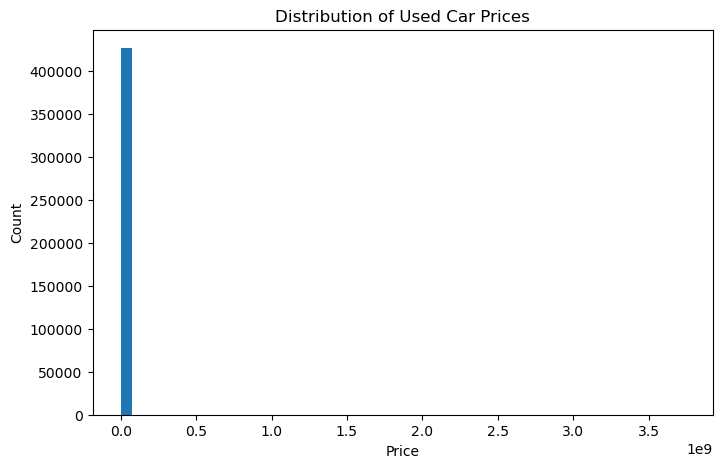

In [5]:
plt.figure(figsize=(8,5))
plt.hist(vehicles['price'].dropna(), bins=50)
plt.title("Distribution of Used Car Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

### 2.2 Outlier Removal ###

Due to extreme left skew of data, remove outliers using IQR

56995


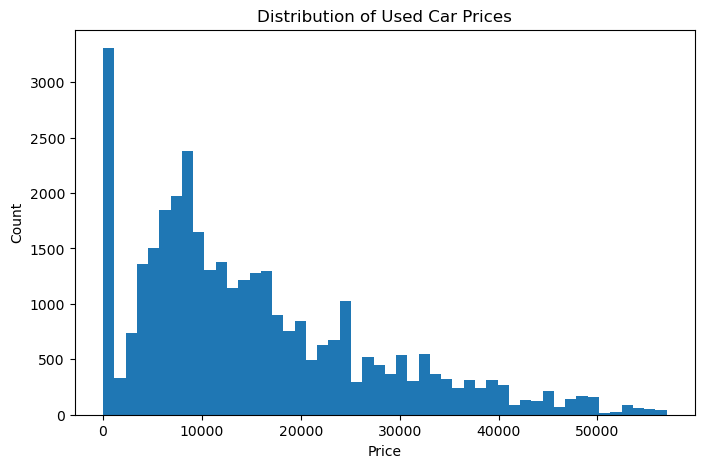

In [ ]:
Q1 = vehicles['price'].quantile(0.25)
Q3 = vehicles['price'].quantile(0.75)
IQR = Q3 - Q1

## Define limits
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# vehicles['log_price'] = np.log1p(vehicles['price'])

vehicles_clean = vehicles[(vehicles['price'] >= lower_bound) & (vehicles['price'] <= upper_bound)].dropna()

plt.figure(figsize=(8,5))
plt.hist(vehicles_clean['price'], bins=50)
plt.title("Distribution of Used Car Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()


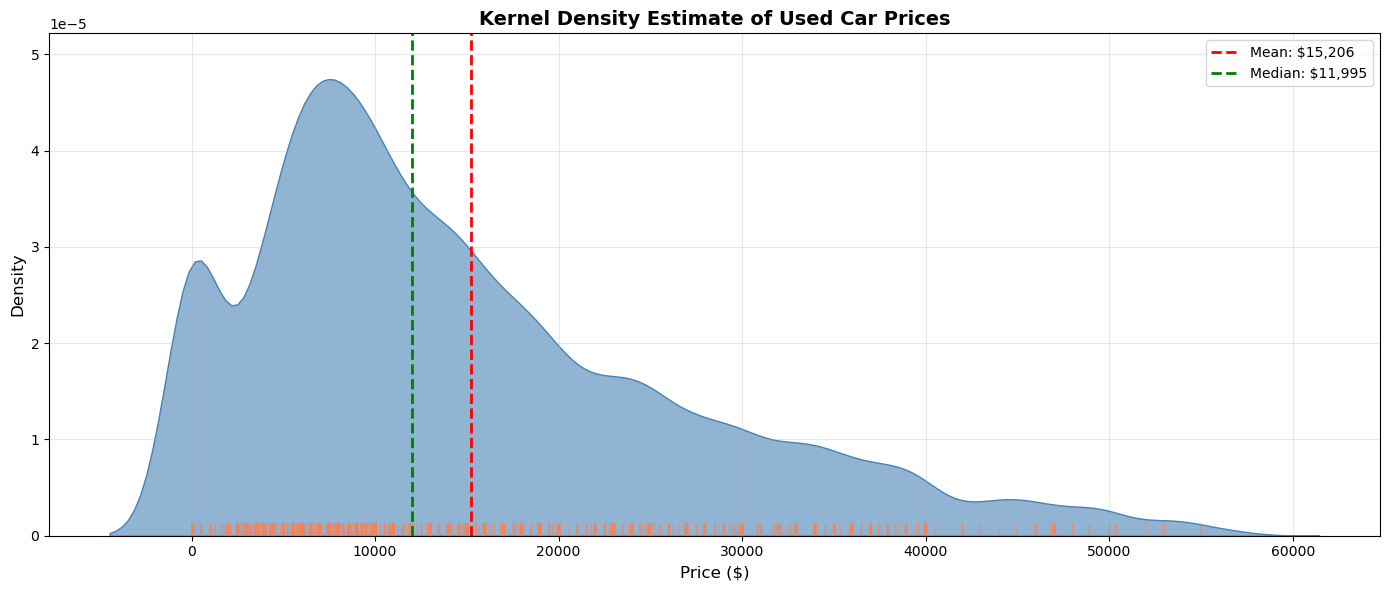

In [20]:
## KDE Plot for 
fig, ax = plt.subplots(figsize=(14, 6))

# KDE plot
sns.kdeplot(data=vehicles_clean, x='price', fill=True, color='steelblue', alpha=0.6, ax=ax)

# Add rug plot (small vertical lines for each data point) - sample for performance
sample = vehicles_clean.sample(min(1000, len(vehicles_clean)), random_state=42)
sns.rugplot(data=sample, x='price', color='coral', alpha=0.5, ax=ax)

# Add mean and median lines
ax.axvline(vehicles_clean['price'].mean(), color='red', linestyle='--', 
           linewidth=2, label=f"Mean: ${vehicles_clean['price'].mean():,.0f}")
ax.axvline(vehicles_clean['price'].median(), color='green', linestyle='--', 
           linewidth=2, label=f"Median: ${vehicles_clean['price'].median():,.0f}")

ax.set_xlabel("Price ($)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Kernel Density Estimate of Used Car Prices", fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 2.2 Univariate Analysis for Numeric Features 

           year     price
year   1.000000  0.268246
price  0.268246  1.000000
          odometer     price
odometer  1.000000 -0.073328
price    -0.073328  1.000000


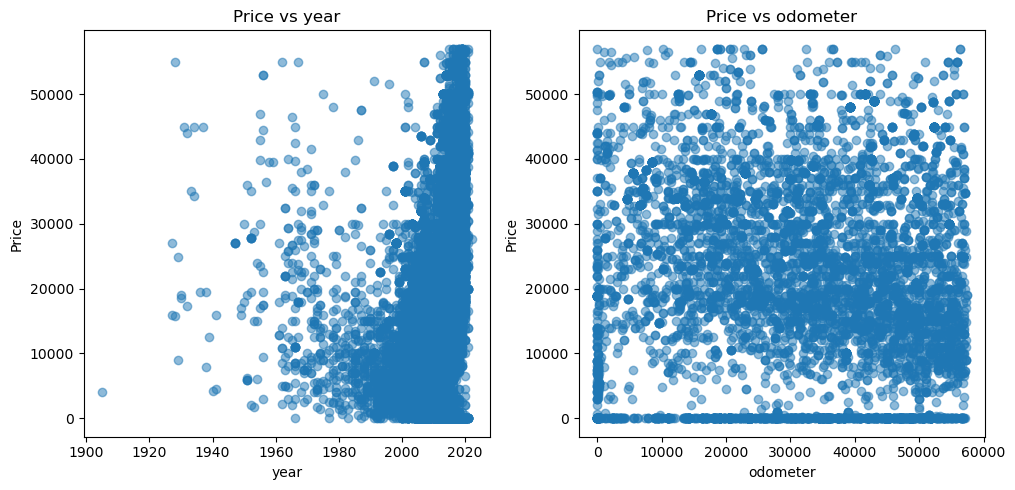

In [13]:
# Select numeric columns
numeric_cols = vehicles_clean.select_dtypes(include=[np.number]).columns.tolist()

# Remove 'id' and 'price' from numeric columns (we don't want to plot price vs. itself or id)
numeric_cols = [col for col in numeric_cols if col not in ['id', 'price', 'log_price']]

# Create scatter plots
num_plots = len(numeric_cols)
rows = (num_plots // 3) + 1  # Arrange plots in rows of 3
plt.figure(figsize=(15, rows * 5))  # Adjust overall figure size


for i, col in enumerate(numeric_cols):
    vehicles_clean = vehicles_clean[(vehicles_clean[col] >= lower_bound) & (vehicles_clean[col] <= upper_bound)].dropna()
    plt.subplot(rows, 3, i + 1)  # Create a subplot for each column
    plt.scatter(vehicles_clean[col], vehicles_clean['price'], alpha=0.5)
    plt.title(f"Price vs {col}")
    plt.xlabel(col)
    plt.ylabel('Price')
    print(vehicles_clean[[col, 'price']].corr())

plt.tight_layout()
plt.show()

### 2.3 Categorical Analysis

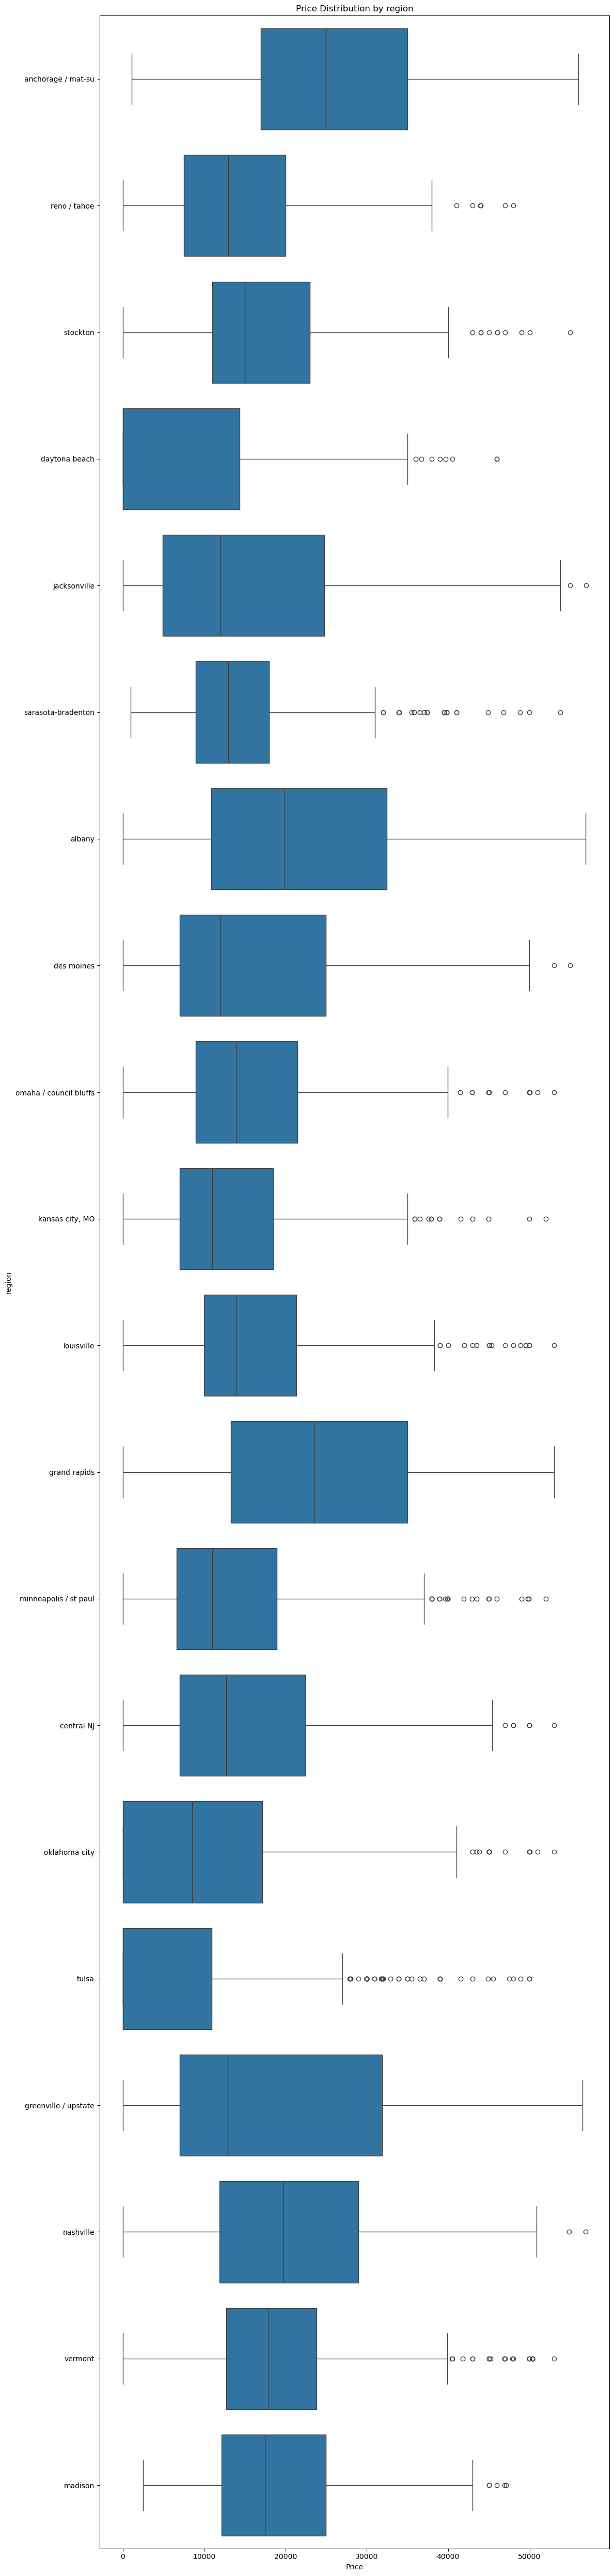

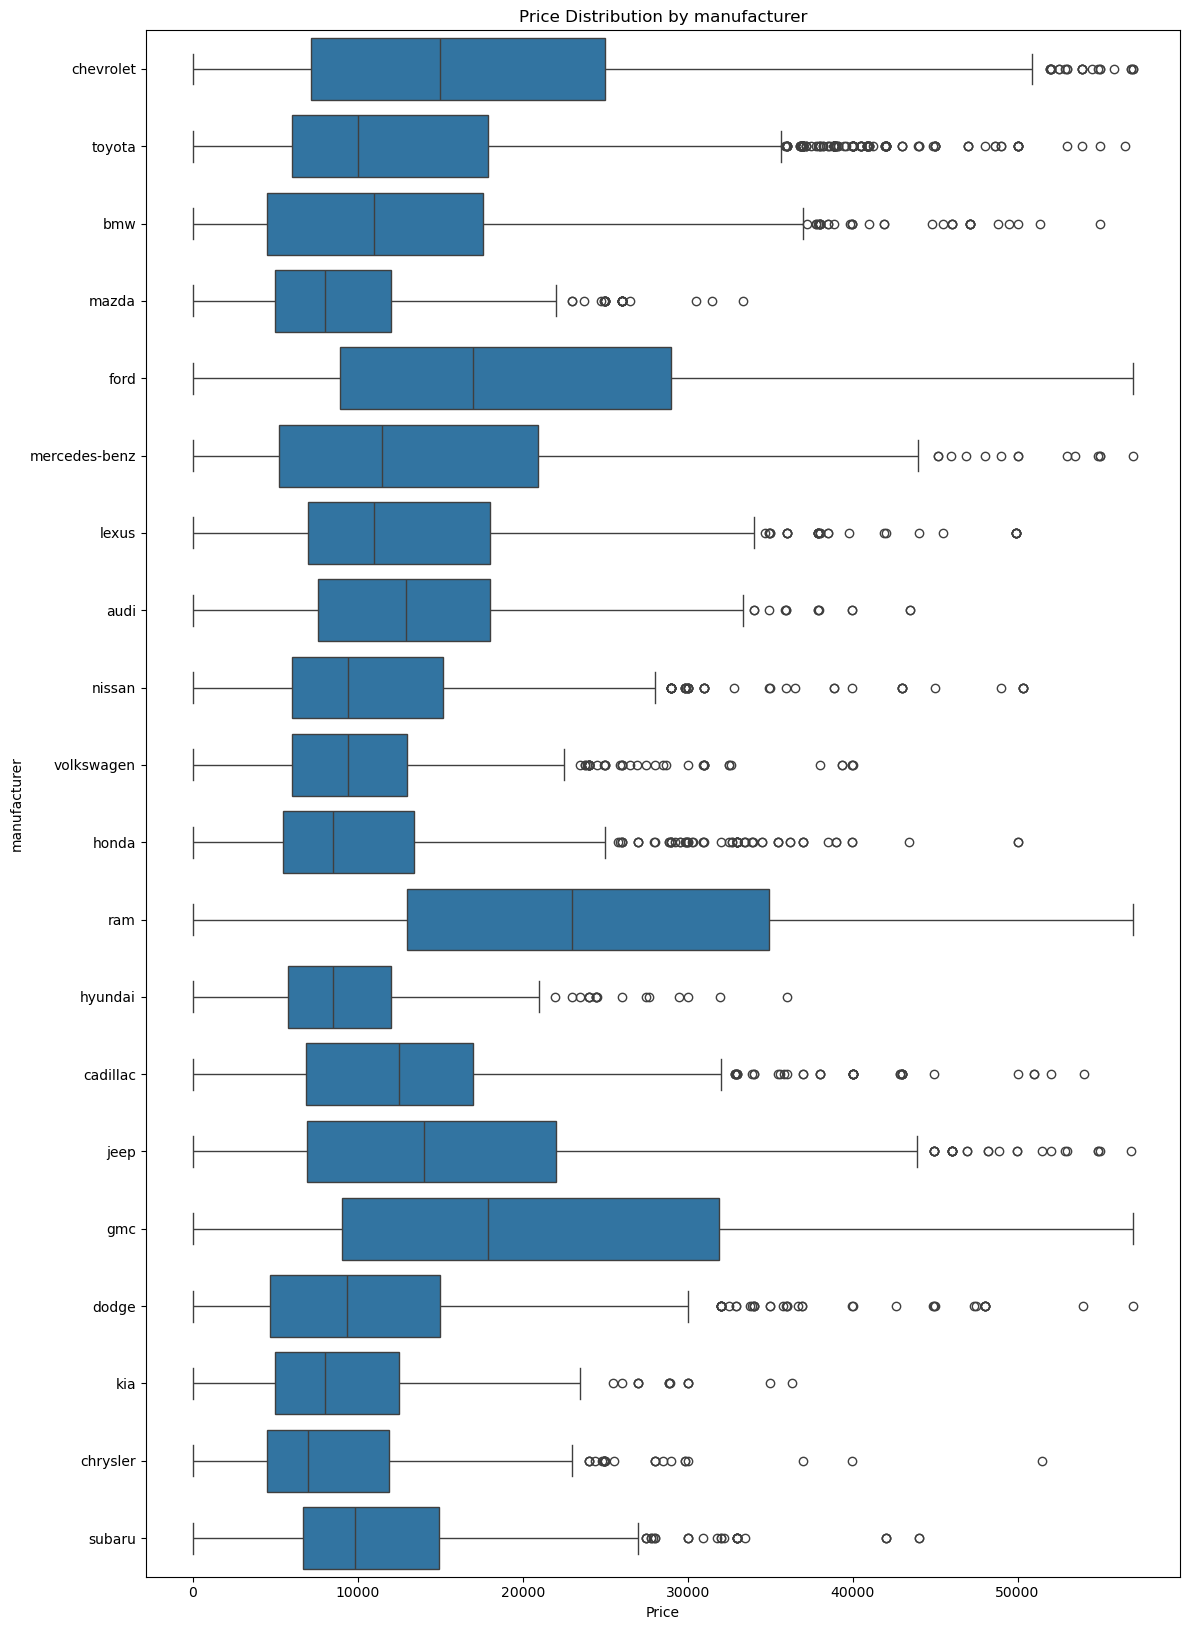

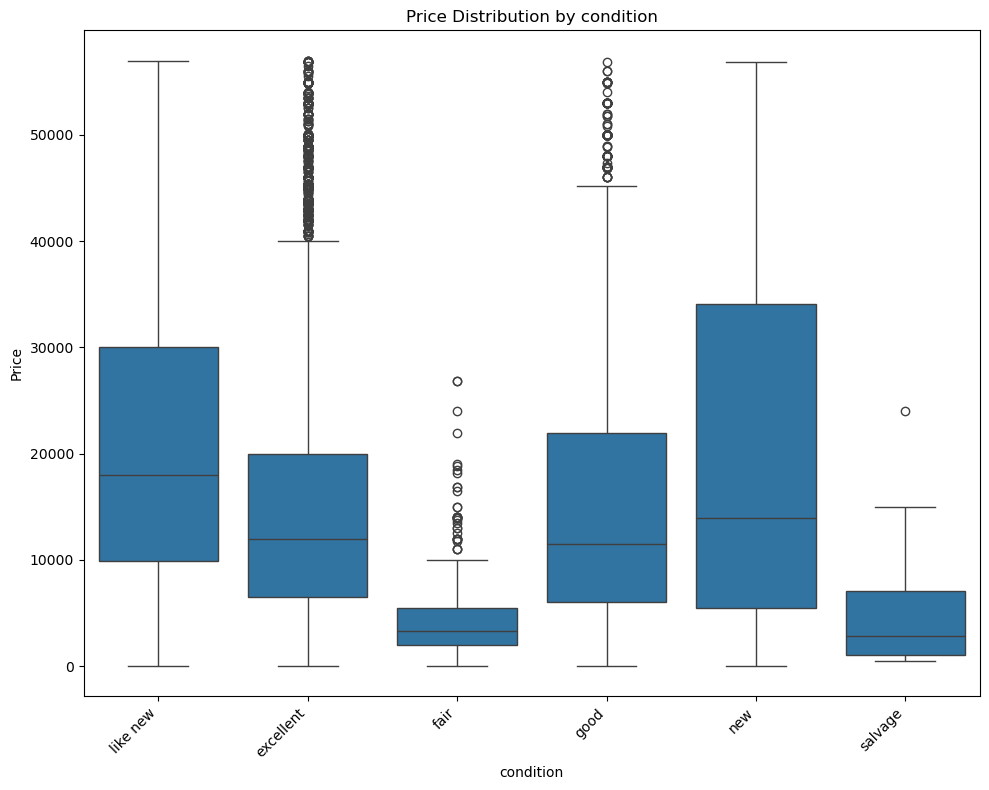

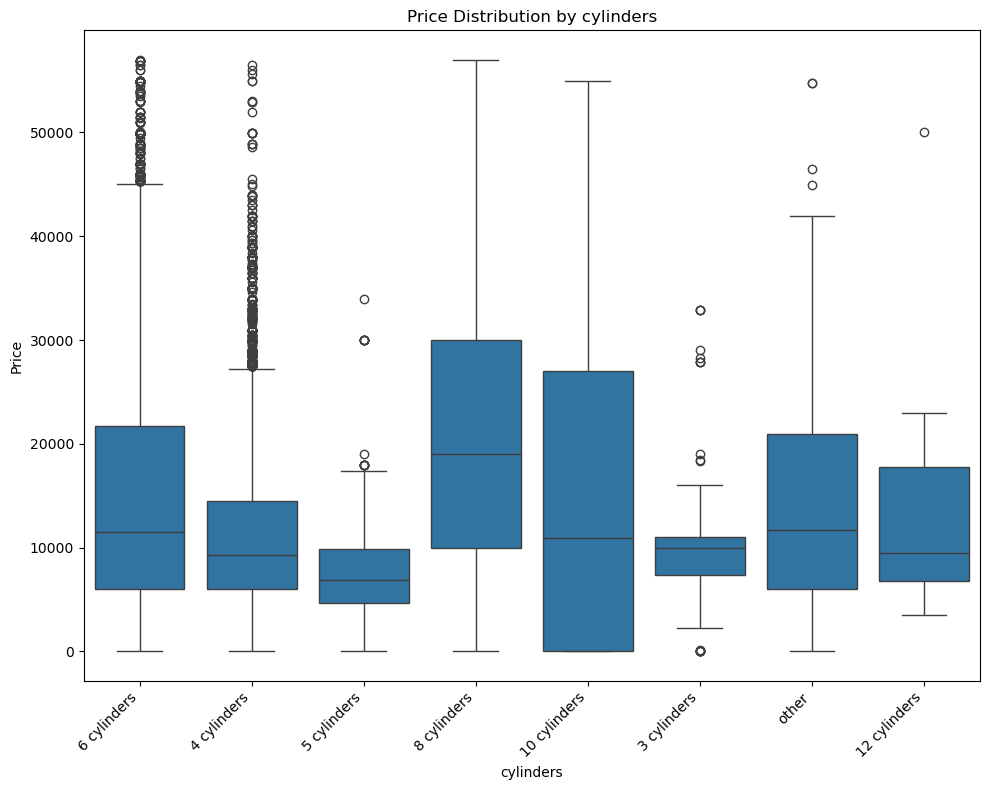

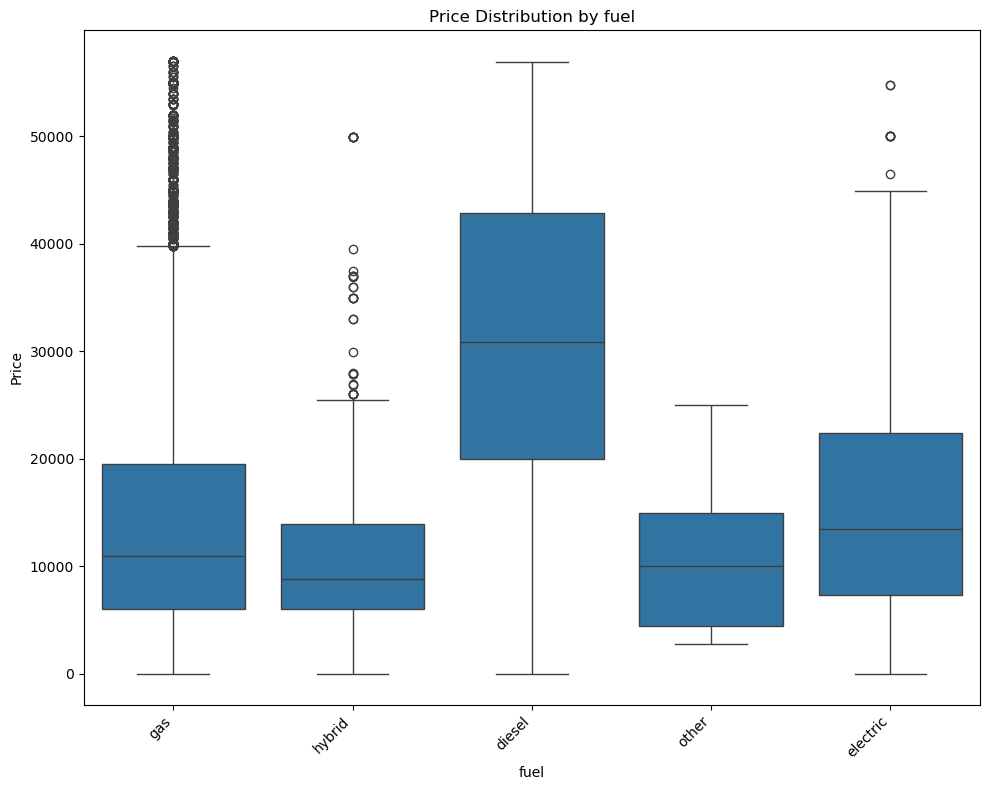

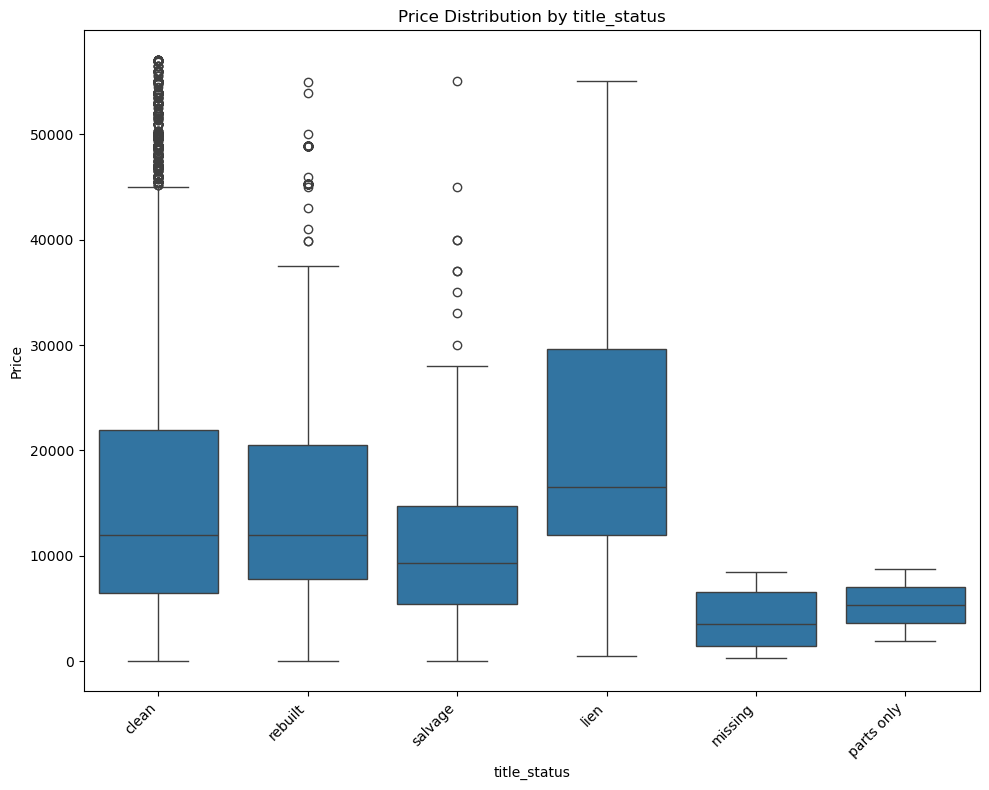

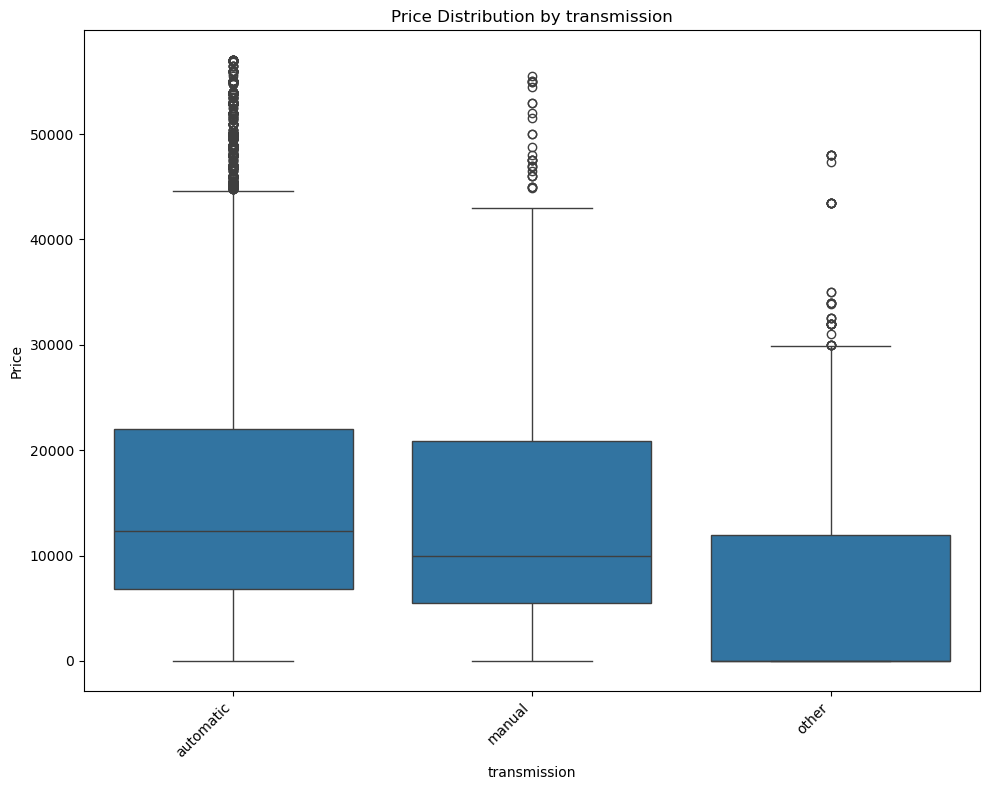

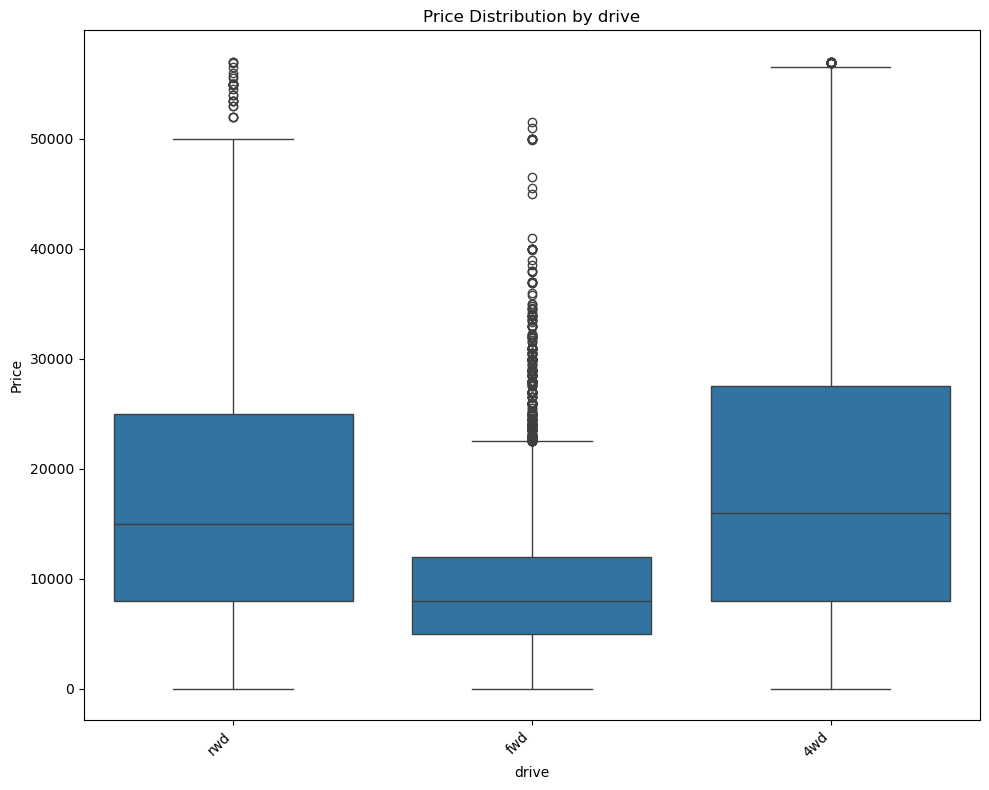

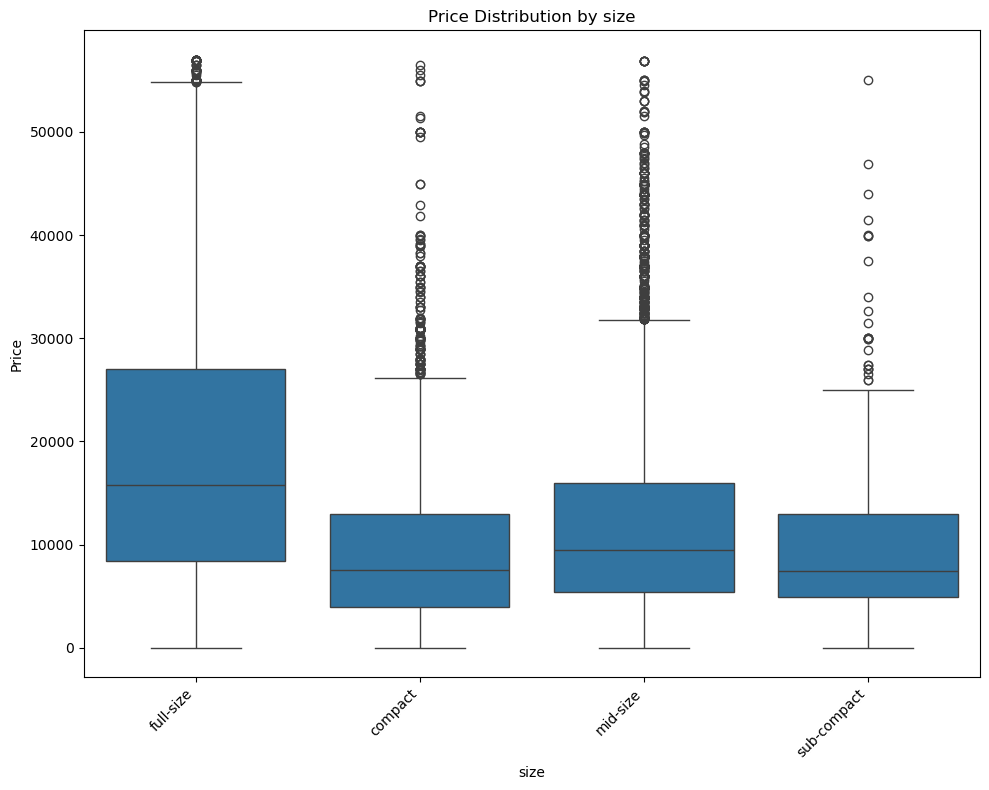

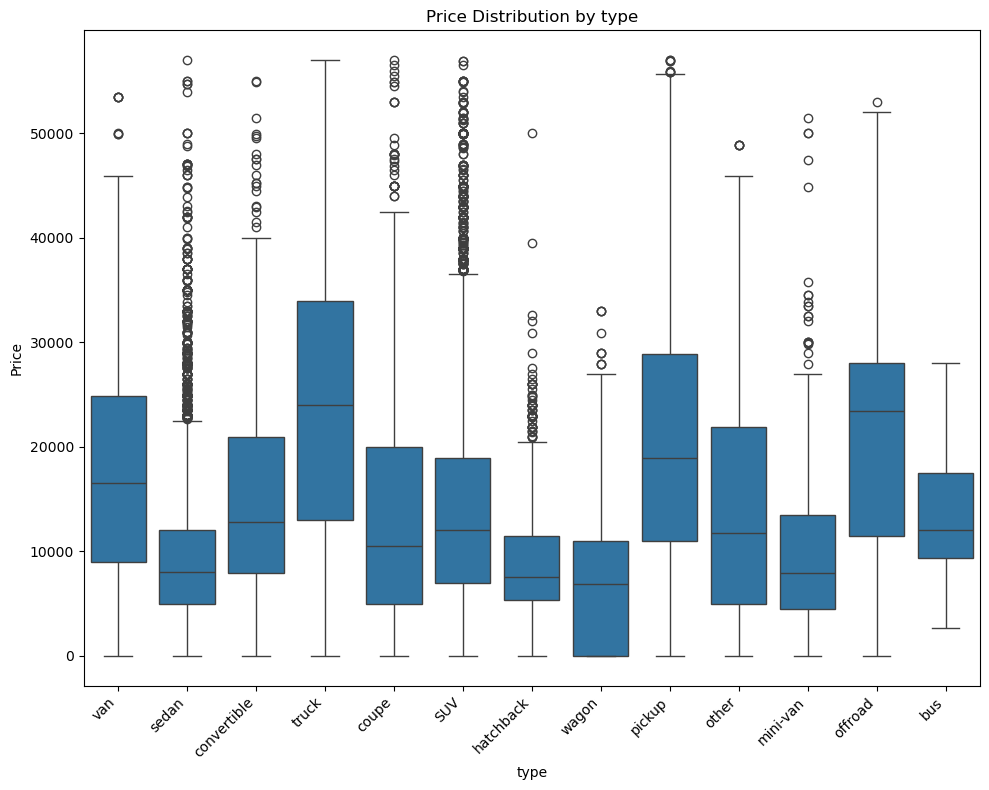

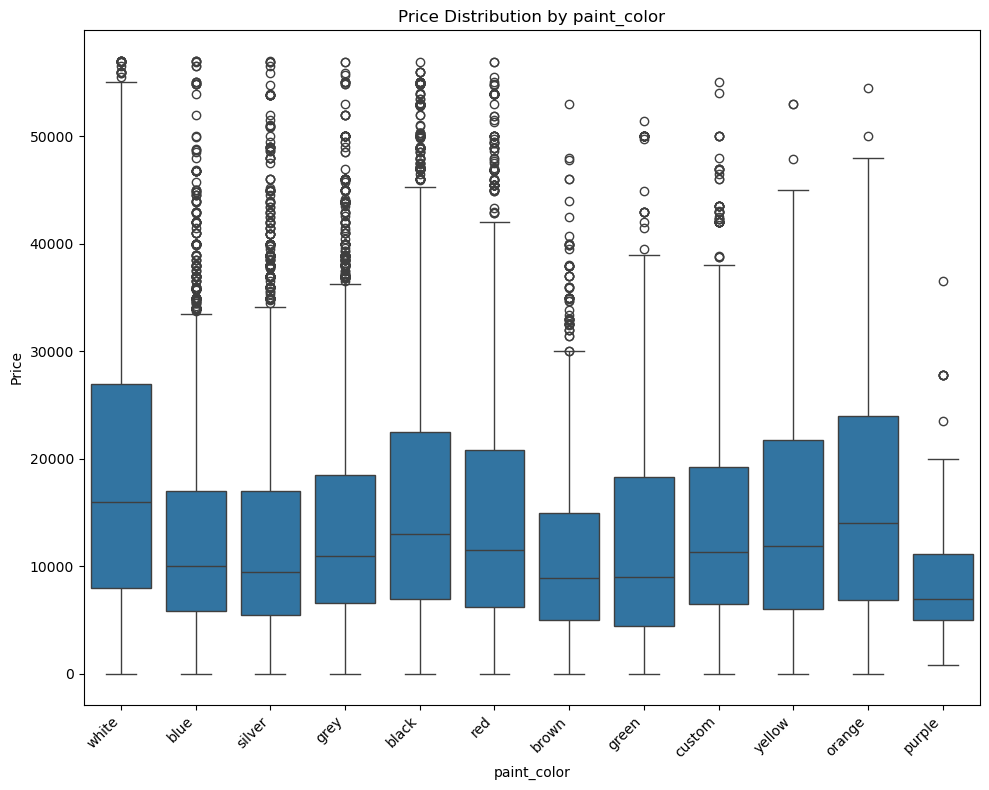

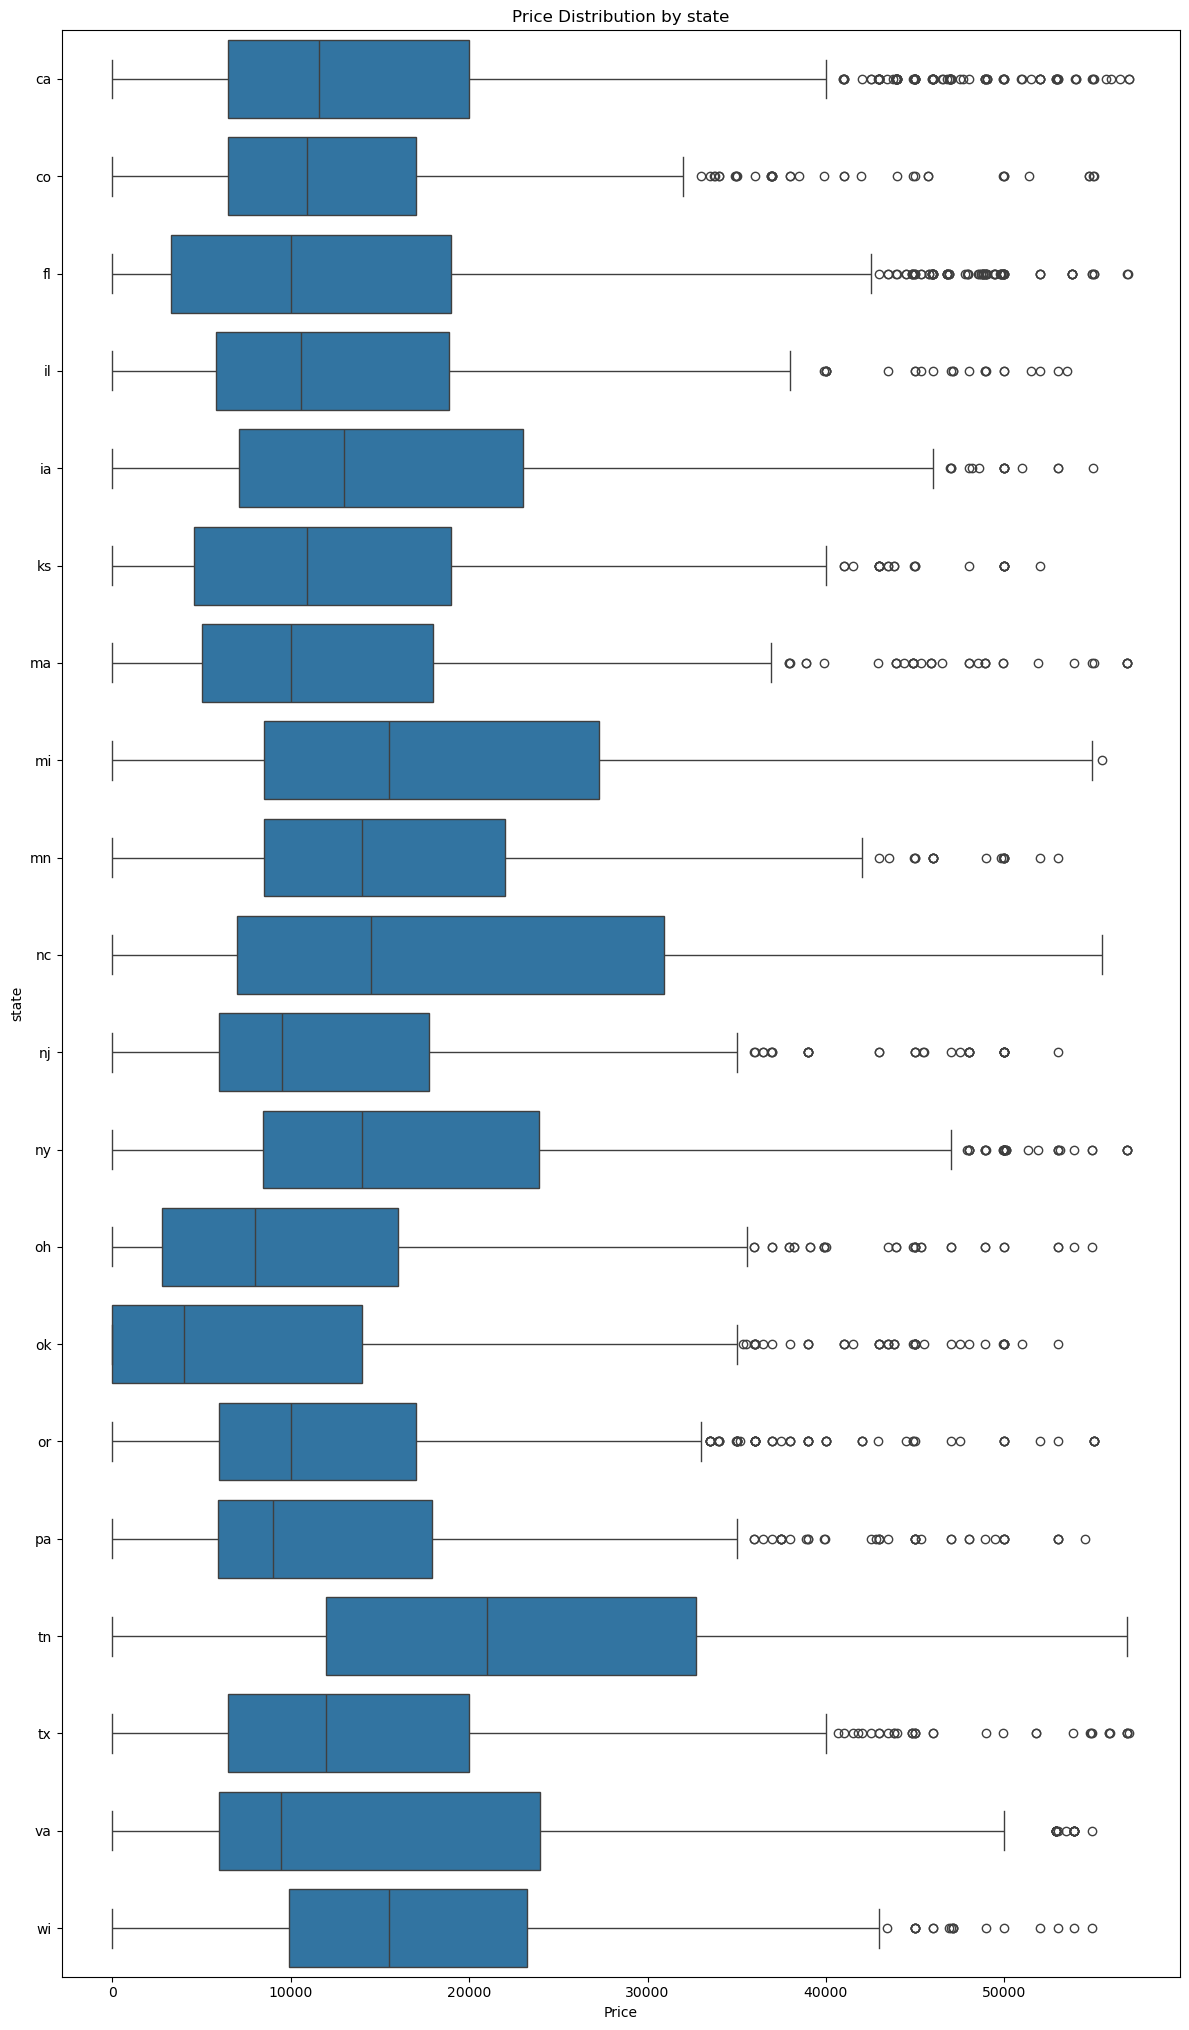

In [8]:
categorical_cols = vehicles.select_dtypes(include=["object"]).columns.tolist()
categorical_cols.remove('VIN')
categorical_cols.remove('model')
categorical_cols

# Box plots for categorical columns against price
for col in categorical_cols:
    unique_values = vehicles_clean[col].nunique()
    
    if unique_values > 20:  # Use horizontal box plot for many categories
        top_vals = vehicles_clean[col].value_counts().head(20).index
        plt.figure(figsize=(12, min(unique_values * 0.4, 50)))  # Adjust height dynamically
        sns.boxplot(y=col, x='price', data=vehicles_clean[vehicles_clean[col].isin(top_vals)])
        plt.title(f"Price Distribution by {col}")
        plt.xlabel('Price')
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()
        
    else:  # Use vertical box plot for fewer categories
        width = max(10, unique_values * 0.5)
        plt.figure(figsize=(width, 8))
        sns.boxplot(x=col, y='price', data=vehicles_clean)
        plt.title(f"Price Distribution by {col}")
        plt.xlabel(col)
        plt.ylabel('Price')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

# 2.4 Bivariate Analysis

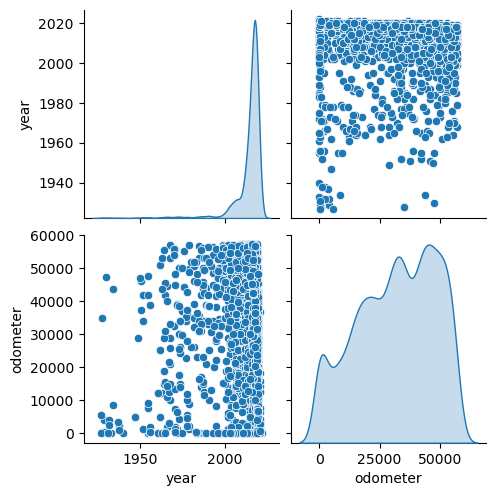

['region', 'manufacturer', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'size', 'type', 'paint_color', 'state']


In [14]:
if len(numeric_cols) > 1:
    sns.pairplot(vehicles_clean[numeric_cols].dropna(), diag_kind="kde")
    plt.show()

print(categorical_cols)

### Data Preparation ###



In [15]:
# Remove rows with zero/negative price
vehicles_clean = vehicles_clean[vehicles_clean['price'] > 0]

# Change type of object columns to category
vehicles_clean[categorical_cols] = vehicles_clean[categorical_cols].astype('object')

model_cols = ['price', 'year', 'odometer', 'manufacturer', 'condition', 'cylinders', 'fuel', 'transmission', 'type', 'state']

vehicles_model = vehicles_clean[model_cols].copy()

In [ ]:
ohe_cols = ['manufacturer', 'fuel', 'cylinders', 'transmission', 'type', 'state']

vehicles_encoded = pd.get_dummies(vehicles_model, columns=ohe_cols, drop_first=True)
# Define the column transformer
ordinal_encoder = OrdinalEncoder(
    categories=[['salvage', 'fair', 'good', 'excellent', 'like new', 'new']]
)

vehicles_encoded['condition'] = ordinal_encoder.fit_transform(vehicles_encoded[['condition']])

scaler = StandardScaler()
vehicles_encoded[numeric_cols] = scaler.fit_transform(vehicles_encoded[numeric_cols])

vehicles_encoded.head()

56995

In [22]:
X = vehicles_encoded.drop('price', axis=1)
y = vehicles_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((4998, 115), (1250, 115))

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [23]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lr = lin_reg.predict(X_test)

rmse_lr = root_mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print(f"Linear Regression RMSE: {rmse_lr:,.2f}")
print(f"Linear Regression MAE : {mae_lr:,.2f}")

Linear Regression RMSE: 8,649.13
Linear Regression MAE : 6,208.44


# 4.2 Cross-Validation for Linear Regression Model

In [ ]:
cv_scores = cross_val_score(
  lin_reg, X_train, y_train,
  scoring='neg_root_mean_squared_error',
  cv=5
)

rmse_cv = -cv_scores

print('Cross-validated RSME (mean +- std): ' f"{rmse_cv.mean():,.2f} +- {rmse_cv.std():.2f}")

Cross-validated RSME (mean +- std): 8,895.88 += 276.49


In [25]:
ridge = Ridge()
ridge_params = {'alpha': [0.1, 1.0, 10.0, 100.0]}

ridge_grid = GridSearchCV(
    ridge,
    ridge_params,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

print("Best Ridge params:", ridge_grid.best_params_)
print("Best Ridge CV RMSE:", -ridge_grid.best_score_)

Best Ridge params: {'alpha': 10.0}
Best Ridge CV RMSE: 8865.762888543546


In [26]:
best_ridge = ridge_grid.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)

rmse_ridge = root_mean_squared_error(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

print(f"Ridge Test RMSE: {rmse_ridge:,.2f}")
print(f"Ridge Test MAE : {mae_ridge:,.2f}")

Ridge Test RMSE: 8,642.49
Ridge Test MAE : 6,245.95


Lasso Regression with Grid Search

In [ ]:
# 4.4 Lasso Regression with Grid Search
lasso = Lasso(max_iter=10000)

lasso_params = {'alpha': [0.001, 0.01, 0.1, 1.0]}

lasso_grid = GridSearchCV(
    lasso,
    lasso_params,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)


print("Best Lasso params:", lasso_grid.best_params_)
print("Best Lasso CV RMSE:", -lasso_grid.best_score_)

best_lasso = lasso_grid.best_estimator_
y_pred_lasso = best_lasso.predict(X_test)

rmse_lasso = root_mean_squared_error(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

print(f"Lasso Test RMSE: {rmse_lasso:,.2f}")
print(f"Lasso Test MAE : {mae_lasso:,.2f}")

Best Lasso params: {'alpha': 1.0}
Best Lasso CV RMSE: 8883.64277088029
Lasso Test RMSE: 8,638.49
Lasso Test MAE : 6,211.65


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [29]:
results = pd.DataFrame({
    'model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'RMSE': [rmse_lr, rmse_ridge, rmse_lasso],
    'MAE': [mae_lr, mae_ridge, mae_lasso]
})

print(results)

               model         RMSE          MAE
0  Linear Regression  8649.134258  6208.435225
1   Ridge Regression  8642.493788  6245.949387
2   Lasso Regression  8638.487831  6211.648690


In [34]:
## Choose the model with the lowest RMSE for interpretation

best_model = results[results['RMSE'] == results['RMSE'].min()]

print(f"Best model is {best_model['model']}")

Best model is 2    Lasso Regression
Name: model, dtype: object


In [44]:
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': best_lasso.coef_
}).sort_values(by='coefficient', ascending=False)

print('Best 20 coefficients')
print(coef_df.head(20))
print('Least 20 coefficients')
print(coef_df.tail(20))
print(coef_df[coef_df['feature'] == 'year'])

Best 20 coefficients
                        feature   coefficient
12         manufacturer_ferrari  17842.309026
4     manufacturer_aston-martin  12104.574061
33           manufacturer_rover  11562.921998
44       cylinders_12 cylinders  11527.415489
36           manufacturer_tesla  10989.449689
31         manufacturer_porsche   8949.632185
39           manufacturer_volvo   8736.741533
62                   type_truck   7458.590666
49        cylinders_8 cylinders   7160.705439
3       manufacturer_alfa-romeo   6302.804176
60                  type_pickup   6068.436498
48        cylinders_6 cylinders   5153.633284
5             manufacturer_audi   5040.448381
25   manufacturer_mercedes-benz   4783.731675
114                    state_wy   4698.748421
22           manufacturer_lexus   3772.405869
58                 type_offroad   3266.622199
59                   type_other   3210.299101
85                     state_me   2349.421445
100                    state_ok   2072.637552
Least 20 coef

<Axes: >

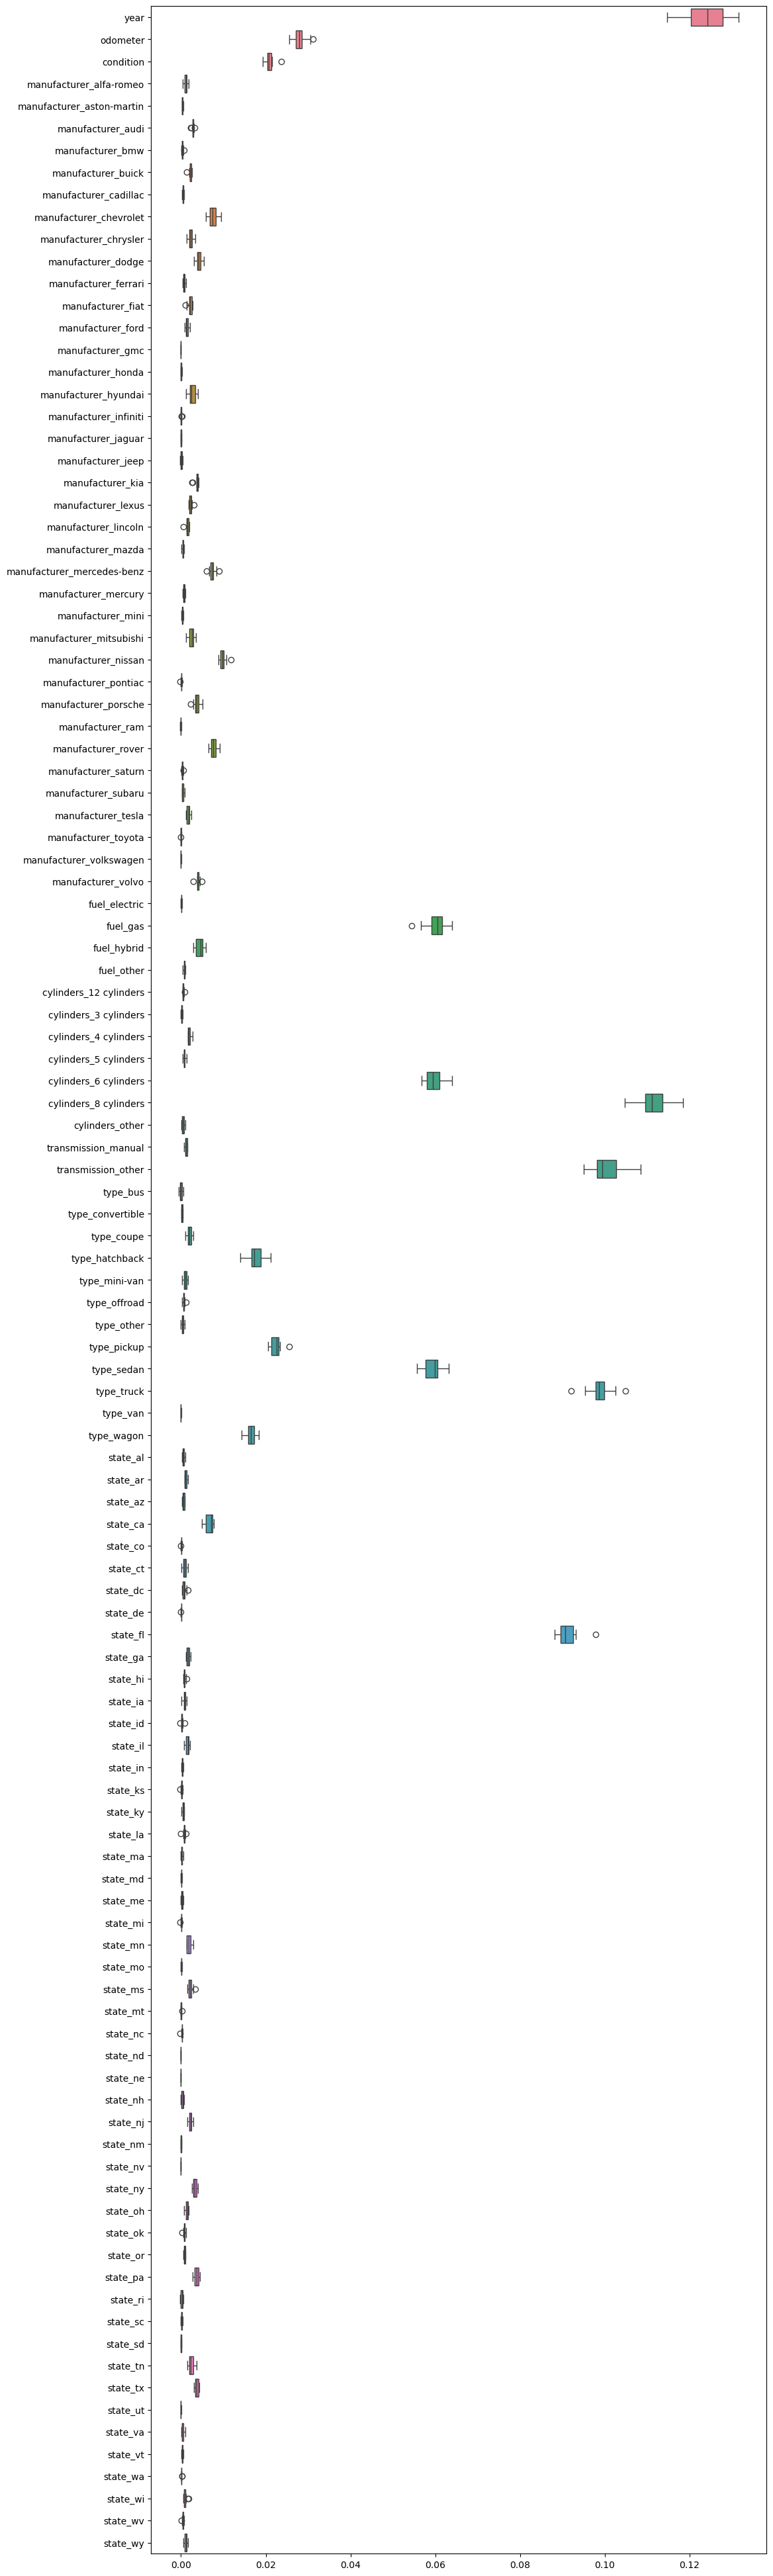

In [ ]:
from sklearn.inspection import permutation_importance
import plotly.express as px

perm_importance = permutation_importance(best_lasso, X, y, n_repeats = 10)

df = pd.DataFrame(perm_importance['importances'])

df = df.T
df.columns = X.columns.tolist()

px.box(data_frame=df, orientation='h', title = 'Feature importance for wage prediction')

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.